#TEXT CLASSIFICATION AND SENTIMENT ANALYSIS



Improving Customer Satisfaction through Automated Review Sentiment Analysis

Overview

You are a product manager at an e-commerce company like Amazon. Your company receives thousands of customer reviews daily for various products. While ratings are available, they don’t always capture customer sentiment accurately — especially when the text and rating conflict.

Business Problem:

Your goal is to build an automated Sentiment Analysis System to classify incoming product reviews as Positive or Negative. This will help:

•	Monitor product performance in real-time

•	Identify products with sudden spikes in negative
feedback

•	Improve customer satisfaction by addressing complaints faster

Dataset

•	Each row is one Amazon customer review for some product.

•	The dataset has been pre-labeled — so you already know if the review is positive or negative.

•	This is a typical sentiment analysis dataset, often used for training or testing natural language processing (NLP) models.

📊 Rows:
10,000 customer reviews

📑 Columns:

1.	label

o	Type: Text (Categorical)

o	Values: pos (positive) or neg (negative)

o	What it means: The sentiment of the review — whether the customer’s feedback is positive or negative.

2.	review

o	Type: Text

o	Values: Actual text of the review written by the
customer.

o	What it means: What the customer said about the product in their own words — for example: “Excellent Soundtrack! I love it!”

Tasks

Data Cleaning: Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

Exploratory Analysis: Word clouds, sentiment distribution, most common positive/negative words.

Model Development: Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

Validation: Use train/test split, cross-validation, and metrics like accuracy, F1-score.


Submission Guidelines

•	Your submission should include a comprehensive report and the complete codebase.

•	Your code should be well-documented and include comments explaining the major steps.

Evaluation Criteria

•	Correct implementation of data preprocessing and
feature extraction.

•	Accuracy and robustness of the classification model.

•	Depth and insightfulness of the sentiment analysis.

•	Clarity and thoroughness of the evaluation and discussion sections.

•	Overall quality and organization of the report and code.

Good luck, and we look forward to your insightful analysis of the given dataset!


In [17]:
import pandas as pd

df = pd.read_csv(r"amazonreviews.tsv", sep='\t')
print(df.head())
print(df.info())

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


Data Cleaning & Preprocessing

In [18]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

# Remove duplicates & null values
df = df.drop_duplicates()
df = df.dropna()

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Exploratory Data Analysis


Sentiment Distribution

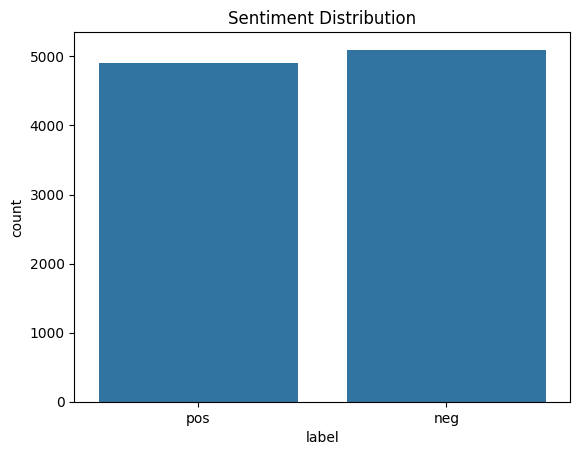

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

Word Cloud

In [20]:
!pip install wordcloud

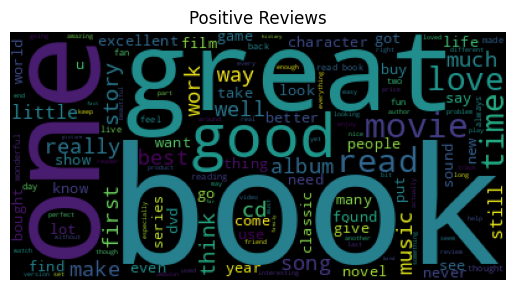

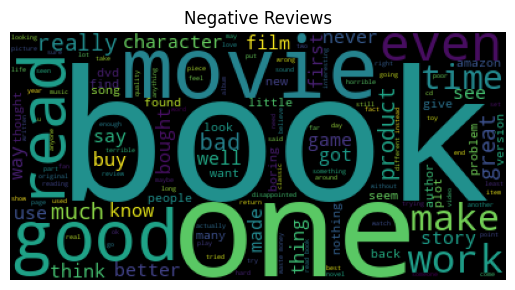

In [21]:
from wordcloud import WordCloud

pos_text = " ".join(df[df['label']=='pos']['clean_review'])
neg_text = " ".join(df[df['label']=='neg']['clean_review'])

wc_pos = WordCloud().generate(pos_text)
wc_neg = WordCloud().generate(neg_text)

plt.imshow(wc_pos)
plt.axis('off')
plt.title("Positive Reviews")
plt.show()

plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews")
plt.show()


Feature Extraction

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['label']

Model Building

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Model Evaluation

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8625
              precision    recall  f1-score   support

         neg       0.87      0.86      0.87      1045
         pos       0.85      0.86      0.86       955

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



Conclusion

In this project, we developed a sentiment analysis model for classifying customer reviews.


Data was cleaned and preprocessed

TF-IDF was used for feature extraction

Logistic Regression model was trained and evaluated

The model can help businesses monitor customer feedback and improve product quality.